---
---

#  Application Project - SingularIT
---
---

# Context
---

- Explaining the Project
- hypothesis final......

### <span style="color:yellow"> **--Imports & Settings--**</span> 
---

In [12]:
import pandas as pd
import numpy as np
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

### <span style="color:lightgreen"> **-- Task - Data--**</span> 
---

### <span style="color:blue"> **--Natesh and Harshitha - Basic Overview with all features included--**</span> 


In [13]:
# Look for all ".json" files
results = glob.glob("results/*.json")
results

['results\\Diana-Hans.json',
 'results\\Diana-Magnus.json',
 'results\\Diana-Olga.json',
 'results\\Diana-Simon.json',
 'results\\Diana-Tanja.json',
 'results\\Hans-Magnus.json',
 'results\\Hans-Olga.json',
 'results\\Hans-Simon.json',
 'results\\Hans-Tanja.json',
 'results\\Magnus-Olga.json',
 'results\\Magnus-Simon.json',
 'results\\Magnus-Tanja.json',
 'results\\Olga-Simon.json',
 'results\\Olga-Tanja.json',
 'results\\Simon-Tanja.json']

In [14]:
file_list = []

for files in results:
    # Open files
    with open(files, "r") as file:
        data = json.load(file)

    events_list = []
    # Assign filename to "game" column
    game = os.path.basename(files).replace(".json", "")

    # Loop through the runs
    for run in data.get("runs", []):
        run_id = run["run_id"]
        player_1 = run["player_1"]
        player_2 = run["player_2"]
        # Loop through events
        for event in run.get("events", []):
            events_list.append({
                "game": game,
                "run_id": run_id,
                "player_1": player_1,
                "player_2": player_2,
                "timestamp": event["timestamp"],
                "player": event["player"],
                "event_type": event["type"],
                "bar": event.get("bar", pd.NA),
                "side": event.get("side", pd.NA),
                "is_goal": event.get("successful", pd.NA)
            })

    # Convert to dataframe
    df_game = pd.DataFrame(events_list)
    file_list.append(df_game)

In [15]:
# Combine dataframes
timestamped_data = pd.concat(file_list, ignore_index=True)
print("Dataframe size:", len(timestamped_data))

Dataframe size: 29337


In [16]:
# Sorting by matchup, run and timestamp
timestamped_data = timestamped_data.sort_values(by=["game", "run_id", "timestamp"]).reset_index(drop=True)

In [17]:
# Replacing all null values to "False"
timestamped_data["is_goal"] = timestamped_data["is_goal"].fillna(False)

In [18]:
# Assigning correct data types
timestamped_data["timestamp"] = pd.to_numeric(timestamped_data["timestamp"], errors="coerce")
timestamped_data["run_id"] = pd.to_numeric(timestamped_data["run_id"], errors="coerce")
timestamped_data["is_goal"] = timestamped_data["is_goal"].astype(bool)

In [19]:
# Create a new column "is_shot"
timestamped_data["is_shot"] = timestamped_data["event_type"] == "shot"

In [20]:
print(timestamped_data["event_type"].value_counts())
print(timestamped_data["player"].value_counts())

event_type
contact    22971
shot        6366
Name: count, dtype: int64
player
Olga      5969
Magnus    5230
Tanja     5100
Simon     5084
Hans      4051
Diana     3903
Name: count, dtype: int64


In [21]:
# Check results
print("Dataset shape:", timestamped_data.shape)
timestamped_data.head()

Dataset shape: (29337, 11)


,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,is_shot
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,False
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,False
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,False
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,True
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,False


In [22]:
# Summary
summary = timestamped_data.groupby(["player", "event_type"]).size().unstack()
summary = summary.fillna(0)
shots = timestamped_data[timestamped_data["event_type"] == "shot"]
success = shots.groupby("player")["is_goal"].sum()
summary["is_goal"] = success
summary["rate"] = summary["is_goal"] / summary["shot"]
summary = summary.fillna(0)
summary

event_type,contact,shot,is_goal,rate
player,,,,
Diana,2959,944,240,0.254237
Hans,2804,1247,162,0.129912
Magnus,4228,1002,186,0.185629
Olga,5305,664,223,0.335843
Simon,3716,1368,219,0.160088
Tanja,3959,1141,189,0.165644


In [23]:
# Side statistics
side_counts = timestamped_data.groupby(["player", "side"]).size().unstack()
side_counts = side_counts.fillna(0)
side_percent = side_counts.div(side_counts.sum(axis=1), axis=0)
side_percent

side,Left,Middle,Right
player,,,
Diana,0.375803,0.436972,0.187225
Hans,0.273181,0.473252,0.253566
Magnus,0.285005,0.455298,0.259697
Olga,0.294628,0.439397,0.265975
Simon,0.293864,0.435145,0.270990
Tanja,0.277090,0.447840,0.275069


In [24]:
# Success rate
shots = timestamped_data[timestamped_data["event_type"] == "shot"]
result = shots.groupby("player")["is_goal"].value_counts().unstack().fillna(0)
result["success_rate"] = result[True] / (result[True] + result[False])
result

is_goal,False,True,success_rate
player,,,
Diana,704,240,0.254237
Hans,1085,162,0.129912
Magnus,816,186,0.185629
Olga,441,223,0.335843
Simon,1149,219,0.160088
Tanja,952,189,0.165644


### <span style="color:orange"> **--Rutvik and Cosima - Advanced Version Where Rounds = Rows--**</span> 

In [25]:
def create_results_table(df):
    is_shot = (df['event_type'] == 'shot')
    is_goal = (df['is_goal'] == True)
    
    df['is_p1_goal'] = is_shot & is_goal & (df['player'] == df['player_1'])
    df['is_p2_goal'] = is_shot & is_goal & (df['player'] == df['player_2'])

    results = df.groupby(['game', 'run_id']).agg({
        'player_1': 'first',
        'player_2': 'first',
        'is_p1_goal': 'sum',
        'is_p2_goal': 'sum'
    }).reset_index()

    results = results.rename(columns={
        'is_p1_goal': 'points_player_1',
        'is_p2_goal': 'points_player_2'
    })

    results['winner'] = np.where(
        results['points_player_2'] > results['points_player_1'], results['player_2'], results['player_1'])
    
    results['loser'] = np.where(
        results['points_player_2'] > results['points_player_1'], results['player_1'], results['player_2'])

    df.drop(columns=['is_p1_goal', 'is_p2_goal'], inplace=True)

    return results

results_table = create_results_table(timestamped_data)

results_table

,game,run_id,player_1,player_2,points_player_1,points_player_2,winner,loser
0,Diana-Hans,0,Diana,Hans,10,5,Diana,Hans
1,Diana-Hans,1,Diana,Hans,10,5,Diana,Hans
2,Diana-Hans,2,Diana,Hans,10,5,Diana,Hans
3,Diana-Hans,3,Diana,Hans,10,4,Diana,Hans
4,Diana-Hans,4,Diana,Hans,10,5,Diana,Hans
...,...,...,...,...,...,...,...,...
70,Simon-Tanja,0,Simon,Tanja,10,8,Simon,Tanja
71,Simon-Tanja,1,Simon,Tanja,9,10,Tanja,Simon
72,Simon-Tanja,2,Simon,Tanja,5,10,Tanja,Simon
73,Simon-Tanja,3,Simon,Tanja,10,6,Simon,Tanja


In [26]:
results_table['winner'].value_counts().reset_index()

,winner,count
0,Diana,22
1,Simon,17
2,Olga,15
3,Magnus,10
4,Tanja,8
5,Hans,3


In [27]:
win_counts = results_table.groupby(['winner', 'loser']).size().reset_index(name='wins')
win_matrix = win_counts.pivot(index='winner', columns='loser', values='wins')
all_players = sorted(list(set(results_table['winner']) | set(results_table['loser'])))
win_matrix.reindex(index=all_players, columns=all_players, fill_value=0)

loser,Diana,Hans,Magnus,Olga,Simon,Tanja
winner,,,,,,
Diana,NaN,5.0,4.0,5.0,3.0,5.0
Hans,NaN,NaN,NaN,1.0,NaN,2.0
Magnus,1.0,5.0,NaN,1.0,1.0,2.0
Olga,NaN,4.0,4.0,NaN,2.0,5.0
Simon,2.0,5.0,4.0,3.0,NaN,3.0
Tanja,NaN,3.0,3.0,NaN,2.0,NaN


In [28]:
timestamped_data['round'] = timestamped_data.groupby(['game', 'run_id'])['is_goal'].shift(fill_value=False).cumsum() + 1 #counts up whenever the previous row was a goal (shift function moves it down 1 row)
timestamped_data['is_contact_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 1 contact
timestamped_data['is_contact_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 2 contact
timestamped_data['is_shot_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 1 shot
timestamped_data['is_shot_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 2 shot

round_data = timestamped_data.groupby(['game', 'run_id', 'round']).agg( #aggregating the data for each round
    start=('timestamp', 'min'), #minimum timestamp in all of the rows for a round -> minimum -> first row
    end=('timestamp', 'max'), #maximum timestamp in all of the rows for a round -> maximum -> last row
    player_1=('player_1', 'first'), #just takes the value of the first row of a round -> doesn't matter because it's the same in all of the rows
    player_2=('player_2', 'first'), 
    contacts_p1=('is_contact_p1', 'sum'), #sum of all the contacts for player 1 (count of True in the boolean column see above)
    contacts_p2=('is_contact_p2', 'sum'), 
    shots_p1=('is_shot_p1', 'sum'),
    shots_p2=('is_shot_p2', 'sum')
).reset_index()

round_data.columns = ['game', 'run_id', 'round', 'start', 'end', 'player_1', 'player_2', 'contacts_p1', 'contacts_p2', 'shots_p1', 'shots_p2']

winners = timestamped_data[timestamped_data['is_goal']].set_index(['game', 'run_id', 'round'])['player'] #filters the goal rows and then extracts the player who shot the goal (=winner) for each round
round_data = round_data.join(winners, on=['game', 'run_id', 'round']).rename(columns={'player': 'round_winner'}) #joins the winner on game, run_id and round

round_data['duration'] = round_data['end'] - round_data['start'] #calculating duration
round_data['p1_won_round'] = (round_data['round_winner'] == round_data['player_1']) #boolean column whether player 1 won the round
round_data['p2_won_round'] = (round_data['round_winner'] == round_data['player_2']) #boolean columns whether player 2 won the round

round_data['points_p1'] = round_data.groupby(['game', 'run_id'])['p1_won_round'].transform('cumsum') #counts up if player 1 won
round_data['points_p2'] = round_data.groupby(['game', 'run_id'])['p2_won_round'].transform('cumsum') #counts up if player 2 won

round_data.drop(columns=['game','p1_won_round', 'p2_won_round'], inplace=True) #dropping unneccessary columns

In [29]:
round_data

,run_id,round,start,end,player_1,player_2,contacts_p1,contacts_p2,shots_p1,shots_p2,round_winner,duration,points_p1,points_p2
0,0,1,2.985530,10.453081,Diana,Hans,2,1,0,1,Hans,7.467551,0,1
1,0,2,20.291921,51.365341,Diana,Hans,5,5,3,2,Diana,31.073420,1,1
2,0,3,56.560030,150.898025,Diana,Hans,15,17,5,7,Diana,94.337994,2,1
3,0,4,164.168779,178.463446,Diana,Hans,3,2,3,1,Diana,14.294667,3,1
4,0,5,191.487753,208.643816,Diana,Hans,4,5,3,2,Hans,17.156064,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214,4,1141,608.090735,738.918799,Simon,Tanja,22,19,9,5,Tanja,130.828064,6,5
1215,4,1142,743.100045,786.364901,Simon,Tanja,10,4,2,1,Simon,43.264856,7,5
1216,4,1143,790.162325,844.426036,Simon,Tanja,13,6,5,3,Simon,54.263711,8,5
1217,4,1144,848.255402,898.807072,Simon,Tanja,7,8,2,4,Simon,50.551670,9,5


# EDA for both Basic Feature Split and Advance Feature Split

# EDA Base Feature 1 - N & H

### Are there differences in the amount of contacts or shots depending on who plays against who?

In [ ]:
# Count events per game
run_counts = timestamped_data.groupby(["game", "run_id", "event_type"]).size()
# Turn event types into columns
run_counts = run_counts.unstack(fill_value=0).reset_index()
# Avg contacts & shots per matchup
avg_counts = run_counts.groupby("game")[["contact", "shot"]].mean().reset_index()
# Add total events column
avg_counts["total"] = avg_counts["contact"] + avg_counts["shot"]
# Sort by total (highest first)
avg_counts = avg_counts.sort_values(by="total", ascending=False)

# Display results
print("Average Events per Game by Matchup:")
display(avg_counts.round(1))

Average Events per Game by Matchup:


event_type,game,contact,shot,total
13,Olga-Tanja,419.0,72.8,491.8
11,Magnus-Tanja,381.6,97.6,479.2
9,Magnus-Olga,396.4,66.0,462.4
10,Magnus-Simon,331.6,104.6,436.2
12,Olga-Simon,354.0,81.0,435.0
8,Hans-Tanja,317.8,105.8,423.6
14,Simon-Tanja,296.8,101.8,398.6
5,Hans-Magnus,288.4,99.0,387.4
6,Hans-Olga,302.0,68.8,370.8
4,Diana-Tanja,263.0,87.0,350.0


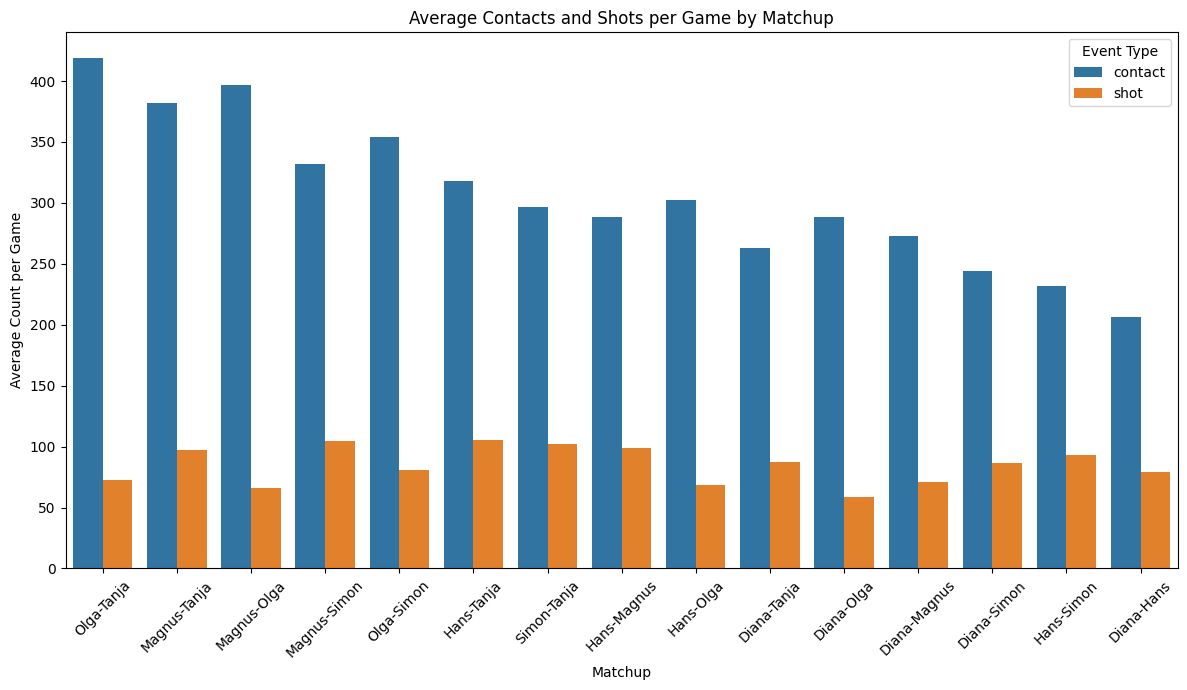

In [ ]:
# Reshape data for plotting
plot_df = avg_counts.melt(
    id_vars="game",
    value_vars=["contact", "shot"],
    var_name="Event Type",
    value_name="Average Count per Game")

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    x="game",
    y="Average Count per Game",
    hue="Event Type")

# Axis labels
plt.xticks(rotation=45)
plt.title("Average Contacts and Shots per Game by Matchup")
plt.xlabel("Matchup")
plt.ylabel("Average Count per Game")
plt.tight_layout()
plt.show()

# EDA Base Feature 2 - N & H

In [ ]:
# Code Here - Natesh & Harshita

# EDA Base Feature 3

In [ ]:
# Code Here - Natesh & Harshita

# Advance Feature EDA 1 (R&C)- Shot Conversion? To understand player traits better?

In [30]:
# Conversion rate is number of successful goals / shot.
timestamped_data['is_shot'] = timestamped_data['event_type'] == 'shot'

player_conversion_rate = timestamped_data.groupby('player').agg(shots=('is_shot','sum'), goals=('is_goal', 'sum')).reset_index()
player_conversion_rate['conversion_rate'] = (player_conversion_rate['goals'] / player_conversion_rate['shots'])


In [31]:
player_conversion_rate

,player,shots,goals,conversion_rate
0,Diana,944,240,0.254237
1,Hans,1247,162,0.129912
2,Magnus,1002,186,0.185629
3,Olga,664,223,0.335843
4,Simon,1368,219,0.160088
5,Tanja,1141,189,0.165644


Text(0.5, 1.0, 'Shot Conversion Rate for each player')

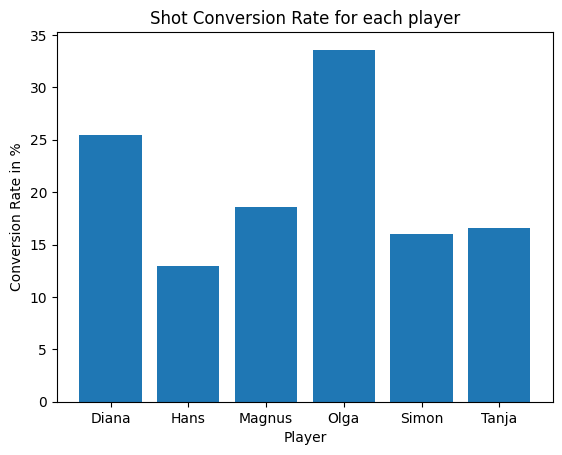

In [32]:
plt.figure()
plt.xlabel('Player')
plt.ylabel('Conversion Rate in %')
plt.bar(player_conversion_rate['player'], (player_conversion_rate['conversion_rate'] * 100))
plt.title('Shot Conversion Rate for each player')

### Advance Feature EDA 2 - Round Duration by player Shots? Does Longer Round = more shots taken?

Text(0.5, 1.0, 'Shorter Round = Less Shots ?')

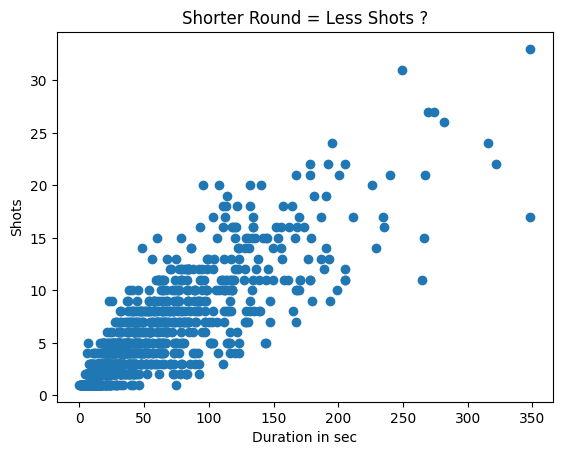

In [33]:
round_data['total_shots'] = (round_data['shots_p1'] + round_data['shots_p2'])
plt.scatter(round_data['duration'], round_data['total_shots'])
plt.xlabel('Duration in sec')
plt.ylabel("Shots")
plt.title('Shorter Round = Less Shots ?')

## Advance Feature EDA 3

In [ ]:
# Code Here - Rutvik & Cosima